In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras import Input
import os

In [2]:
print(tf.config.list_physical_devices('GPU'))
print(len(tf.config.list_physical_devices('GPU')))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
1


In [3]:
data_dir = r'D:\Project\data_kaggle\aug\train_split'

In [4]:
batch_size = 32
img_height = 224
img_width = 224
image_size = (img_height, img_width)
epochs = int(input("Enter epochs number: "))

Enter epochs number:  50


In [5]:
train_datagen = ImageDataGenerator()

train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(224, 224),
    batch_size=batch_size,
    class_mode='categorical',
    color_mode='rgb'  # Force RGB mode
)

Found 5863 images belonging to 8 classes.


In [6]:
val_datagen = ImageDataGenerator()

val_data = r"D:\Project\data_kaggle\aug\val_split"

val_generator = val_datagen.flow_from_directory(
    val_data,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
)

Found 1469 images belonging to 8 classes.


In [7]:
base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(len(train_generator.class_indices), activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

In [8]:
model.summary()

Model: "model"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_1 (InputLayer)            [(None, 224, 224, 3) 0                                            
__________________________________________________________________________________________________
zero_padding2d (ZeroPadding2D)  (None, 230, 230, 3)  0           input_1[0][0]                    
__________________________________________________________________________________________________
conv1/conv (Conv2D)             (None, 112, 112, 64) 9408        zero_padding2d[0][0]             
__________________________________________________________________________________________________
conv1/bn (BatchNormalization)   (None, 112, 112, 64) 256         conv1/conv[0][0]                 
______________________________________________________________________________________________

In [9]:
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [10]:
history = model.fit(
    train_generator,
    epochs=epochs,
    validation_data=val_generator
)

Epoch 1/50
184/184 [==============================] - 84s 315ms/step - loss: 3.0927 - accuracy: 0.2792 - val_loss: 1.4489 - val_accuracy: 0.5010
Epoch 2/50
184/184 [==============================] - 46s 250ms/step - loss: 1.7011 - accuracy: 0.4201 - val_loss: 1.2977 - val_accuracy: 0.5664
Epoch 3/50
184/184 [==============================] - 49s 267ms/step - loss: 1.4551 - accuracy: 0.4933 - val_loss: 1.1849 - val_accuracy: 0.6018
Epoch 4/50
184/184 [==============================] - 47s 254ms/step - loss: 1.3243 - accuracy: 0.5345 - val_loss: 1.0981 - val_accuracy: 0.6406
Epoch 5/50
184/184 [==============================] - 45s 244ms/step - loss: 1.2306 - accuracy: 0.5733 - val_loss: 1.0213 - val_accuracy: 0.6705
Epoch 6/50
184/184 [==============================] - 47s 255ms/step - loss: 1.1394 - accuracy: 0.5908 - val_loss: 0.9629 - val_accuracy: 0.6801
Epoch 7/50
184/184 [==============================] - 47s 252ms/step - loss: 1.0663 - accuracy: 0.6302 - val_loss: 0.9115 - val_ac

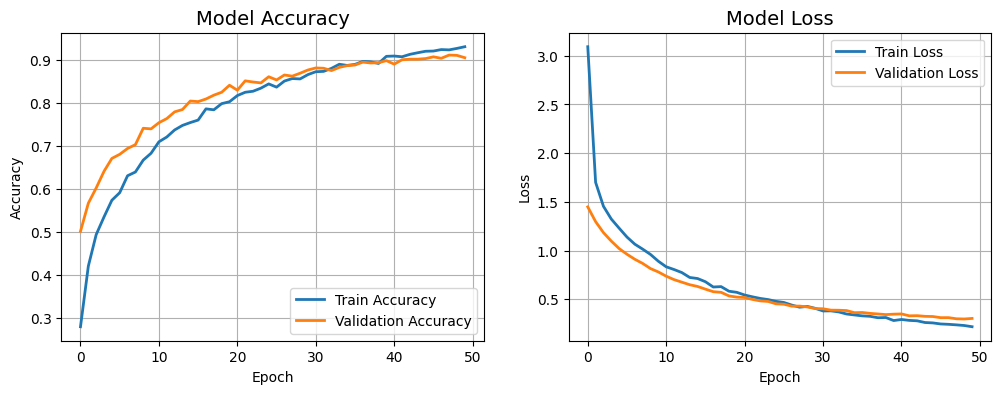

In [11]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
plt.title('Model Accuracy', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('Model Loss', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid()

plt.show()

In [12]:
test_data = r'D:\Project\data_kaggle\test'

eval_generator = train_datagen.flow_from_directory(
    test_data,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

y_true = eval_generator.classes
y_pred = model.predict(eval_generator)

y_pred_classes = np.argmax(y_pred, axis=1)

Found 190 images belonging to 8 classes.


In [13]:
print("\nClassification Report:\n", classification_report(y_true, y_pred_classes))

conf_mat = confusion_matrix(y_true, y_pred_classes)
class_labels = list(train_generator.class_indices.keys())


Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.93      0.96        28
           1       0.61      0.52      0.56        21
           2       0.87      0.80      0.83        25
           3       0.75      0.65      0.70        23
           4       0.64      0.76      0.70        21
           5       0.74      0.61      0.67        23
           6       0.74      1.00      0.85        26
           7       0.88      0.91      0.89        23

    accuracy                           0.78       190
   macro avg       0.78      0.77      0.77       190
weighted avg       0.79      0.78      0.78       190



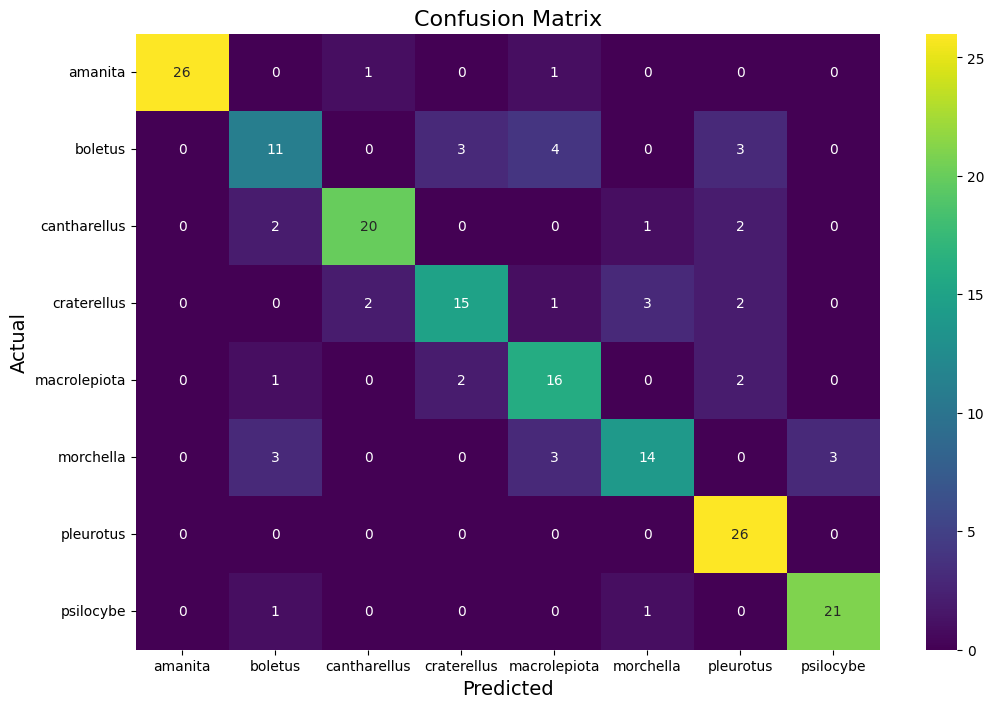

In [14]:
plt.figure(figsize=(12, 8))
sns.heatmap(conf_mat, annot=True, fmt="d", cmap="viridis", xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted', fontsize=14)
plt.ylabel('Actual', fontsize=14)
plt.title('Confusion Matrix', fontsize=16)
plt.show()

In [15]:
model_version = epochs
next_version = str(int(model_version) + 10)

In [16]:
import shutil

notebook_filename = f"CNN_{model_version}_ADAM.ipynb"
new_notebook_filename = f"CNN_{next_version}_ADAM.ipynb"

shutil.copy(notebook_filename, new_notebook_filename)
print(f"Notebook copied as {new_notebook_filename}")

Notebook copied as CNN_60_ADAM.ipynb


In [ ]:
os._exit(00)